# Test du khi2
## Importations

In [144]:
import pandas as pd
from scipy.stats import chi2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency

## Fonction

In [145]:
def khi2(df,colonne1,colonne2,alpha):
    """
    df: le dataframe
    colonne1 et colonne2: nom des colonnes pour le test
    sep: séparateur du csv
    alpha: degré d'erreur
    """

    #tableau de contingence
    tab_contingence = pd.crosstab(df[colonne1],df[colonne2])
    #print("Tableau de contingence:\n",tab_contingence)

    eff_observes = tab_contingence.values #extrait les données du df et les met en array

    #totaux marginaux
    total = eff_observes.sum()
    totaux_lignes = eff_observes.sum(axis=1,keepdims=True)
    totaux_colonnes = eff_observes.sum(axis=0,keepdims=True)

    #Calcul des effectifs théoriques
    theorique = (totaux_lignes*totaux_colonnes)/total
    #print("Effectifs théoriques:\n",pd.DataFrame(theorique,index=tab_contingence.index,columns=tab_contingence.columns))

    condition = (theorique < 5).mean()
    if condition > 0.2:
        print(f"Condition non respectée : {condition*100:.1f}% des cellules < 5. On ne peut pas effectuer le test")
        return

    khi_2 = ((eff_observes-theorique)**2/theorique).sum()

    ddl= (eff_observes.shape[0]-1)*(eff_observes.shape[1]-1)

    p_value = 1 - chi2.cdf(khi_2,ddl)

    print(f"Khi² = {khi_2}")
    print(f"Degrés de liberté = {ddl}")
    print(f"p_value = {p_value}")

    #Interprétation à degré 5%
    if p_value < alpha:
        print(f'Résultat : dépendance significative entre {colonne1} et {colonne2} (p<{alpha})')
    else:
        print(f'Résultat : pas de dépendance significative entre {colonne1} et {colonne2} (p>={alpha})')

In [146]:
def heatmap(df, col1, col2, figsize=(10, 6)):
    """
    Affiche une heatmap pour visualiser la relation entre deux variables catégorielles.
    
    Paramètres :
        df      : DataFrame pandas
        col1    : variable en lignes
        col2    : variable en colonnes
        figsize : taille de la figure
    """
    # Tableau de contingence
    contingency = pd.crosstab(df[col1], df[col2])
    
    # Calcul via scipy
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    # Résidus standardisés
    residuals = (contingency - expected) / np.sqrt(expected)
    
    data = residuals
    title = f"Heatmap entre {col1} et {col2}"
    fmt = ".2f"
    cmap = "RdBu_r"
    center = 0

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        data,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        center=center,
        linewidths=0.5,
        ax=ax
    )
    
    # Statistiques dans le titre
    ax.set_title(f"{title}\nkhi²={chi2:.2f}, p={p:.4f}, ddl={dof}", fontsize=12)
    ax.set_xlabel(col2)
    ax.set_ylabel(col1)
    plt.tight_layout()
    plt.show()

## Création du dataframe

In [ ]:
a_cat = pd.read_csv("gamesale_table_a_categorie.csv")
a_os = pd.read_csv("gamesale_table_a_os.csv")
a_tag = pd.read_csv("gamesale_table_a_tag.csv")
cat = pd.read_csv("gamesale_table_categorie.csv")
dev = pd.read_csv("gamesale_table_developpeur.csv")
editeur = pd.read_csv("gamesale_table_editeur.csv")
genre = pd.read_csv("gamesale_table_genre.csv")
jeux = pd.read_csv("gamesale_table_jeux.csv")
os = pd.read_csv("gamesale_table_os.csv")
# Transformer a_tag de wide (0,1,0...) à long (id_jeu,tag)
a_tag = a_tag.melt(
    id_vars='id_jeu',
    var_name='tag',
    value_name='score'
)
a_tag = a_tag[a_tag['score'] > 0].drop(columns='score')

df = pd.merge(jeux,dev)
df = pd.merge(df,editeur)
df = pd.merge(df,genre)
print(df.head())

   id_jeu                       nom_jeu   annee  age_requis  nb_succes  \
0       1            grand theft auto v  2015.0          18         77   
1       2  grand theft auto san andreas  2008.0          18          0   
2       3    grand theft auto vice city  2011.0          18          0   
3       4        call of duty black ops  2010.0          18         68   
4       5     call of duty black ops ii  2012.0          18         35   

   nb_avis_pos  nb_avis_neg  temps_jeu_moyen   prix  \
0       329061       139308             9837  24.99   
1        26877         3243              807   9.99   
2         9817          819              209   5.99   
3        14201         1839             2672  29.99   
4        25827         4658              524  39.99   

                                         description  ... ventes_EU ventes_JP  \
0  Los Santos is a city of bright lights, long ni...  ...     23,04      1,39   
1  Five years ago Carl Johnson escaped from the p...  ...     

## Genre et éditeur
La condition de la fréquence attendue au dessus de 5 pour chaque cellule n'est pas respectée. Nous avons beau regrouper des éditeurs et des genres avant de faire le test, le test est infaisable.

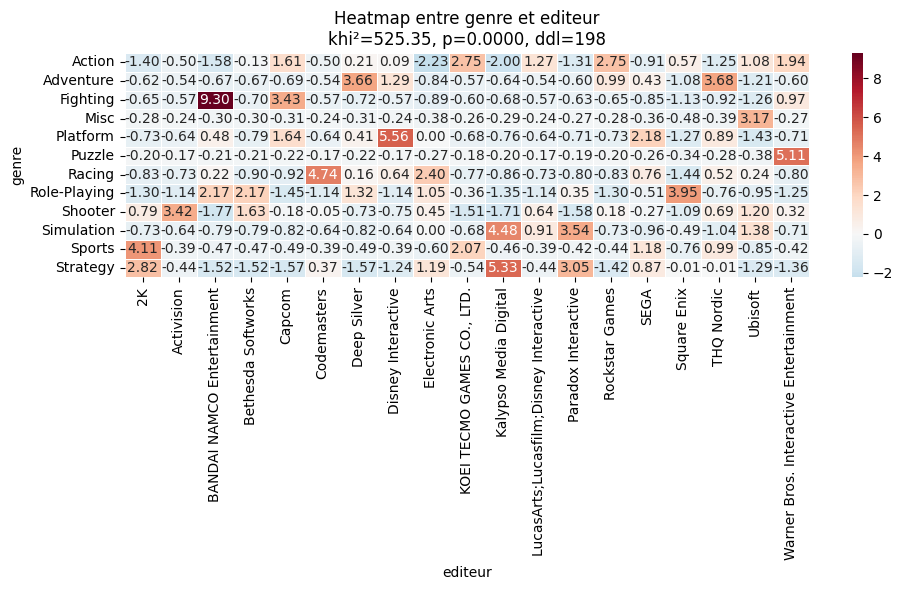

Condition non respectée : 94.7% des cellules < 5. On ne peut pas effectuer le test


In [148]:
seuil = 10

top_editeurs = df["editeur"].value_counts()
top_editeurs = top_editeurs[top_editeurs >= seuil].index

top_genres = df["genre"].value_counts()
top_genres = top_genres[top_genres >= seuil].index

df_filtre = df[
    df["editeur"].isin(top_editeurs) &
    df["genre"].isin(top_genres)
]

heatmap(df_filtre, "genre", "editeur")
khi2(df_filtre, "genre", "editeur", 0.05)

## Genre et développeur

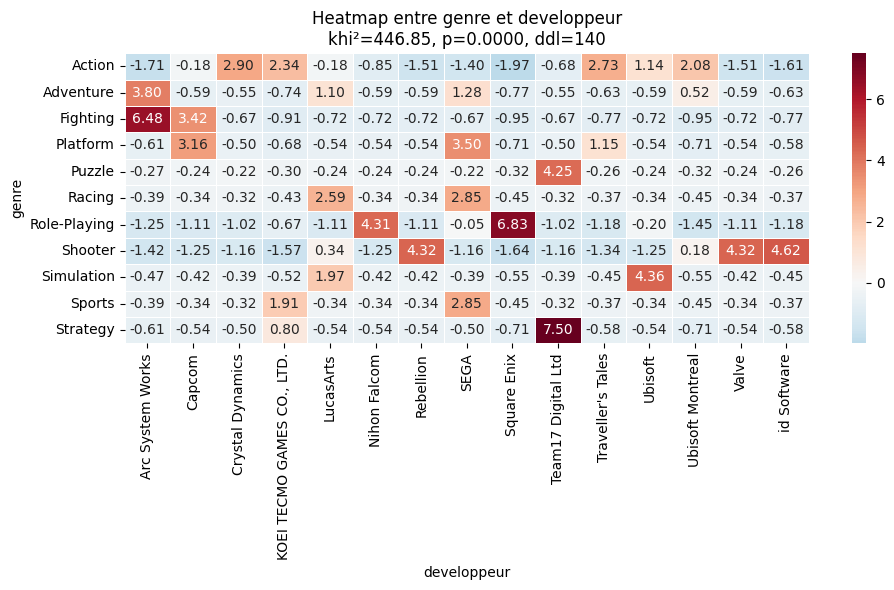

Condition non respectée : 100.0% des cellules < 5. On ne peut pas effectuer le test


In [149]:
seuil = 6
top_developpeur = df["developpeur"].value_counts()
top_developpeur = top_developpeur[top_developpeur >= seuil].index

seuil_genre=0
top_genres = df["genre"].value_counts()
top_genres = top_genres[top_genres >= seuil_genre].index

df_filtre = df[
    df["developpeur"].isin(top_developpeur) &
    df["genre"].isin(top_genres)
]

heatmap(df_filtre,"genre","developpeur")
khi2(df_filtre,"genre","developpeur",0.05)

## Genre et catégorie

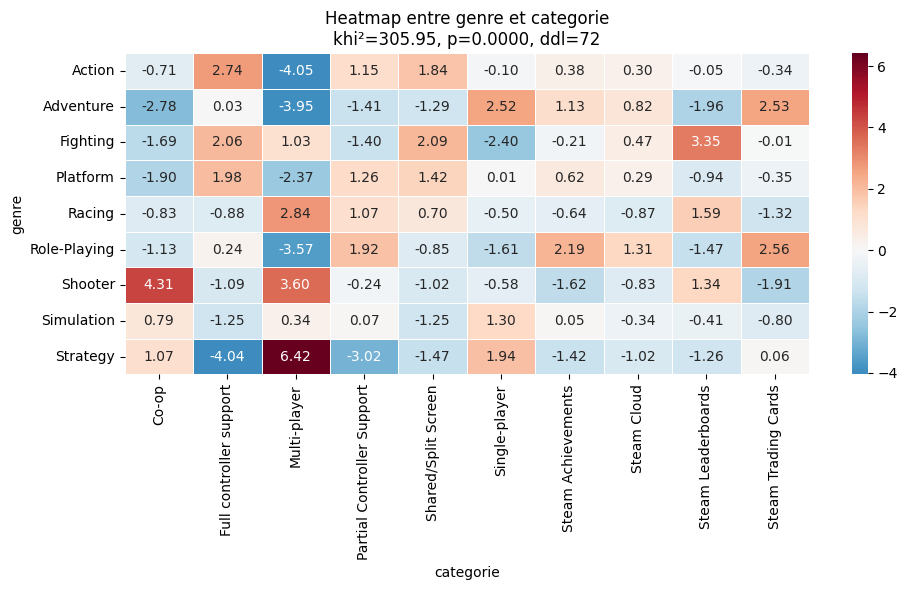

Khi² = 305.95368324107824
Degrés de liberté = 72
p_value = 0.0
Résultat : dépendance significative entre genre et categorie (p<0.05)


In [150]:
df_cat = pd.merge(jeux, a_cat, on="id_jeu")
df_cat = pd.merge(df_cat, cat, on="id_cat")
df_cat = pd.merge(df_cat, genre, on="id_jeu")

# Tri des genre sous représentés
seuil = 120
seuil_cat=50

genres_freq = df_cat["genre"].value_counts()
cat_freq = df_cat["categorie"].value_counts()

df_filtre = df_cat[
    df_cat["genre"].isin(genres_freq[genres_freq >= seuil].index) &
    df_cat["categorie"].isin(cat_freq[cat_freq >= seuil_cat].index)
]

heatmap(df_filtre,"genre","categorie")
khi2(df_filtre, "genre", "categorie", 0.05)

## Genre et tag

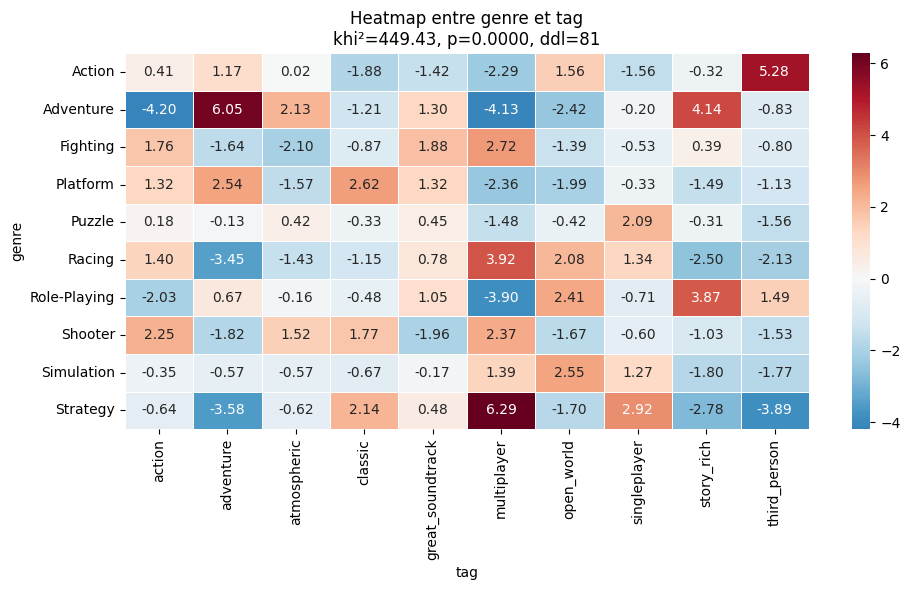

Khi² = 449.42591554736345
Degrés de liberté = 81
p_value = 0.0
Résultat : dépendance significative entre genre et tag (p<0.05)


In [151]:
df_tag = pd.merge(df, a_tag, on="id_jeu")
seuil = 200
top_tag = df_tag["tag"].value_counts()
top_tag = top_tag[top_tag >= seuil].index

seuil_genre=150
top_genres = df_tag["genre"].value_counts()
top_genres = top_genres[top_genres >= seuil_genre].index

df_filtre = df_tag[
    df_tag["tag"].isin(top_tag) &
    df_tag["genre"].isin(top_genres)
]

heatmap(df_filtre,"genre","tag")
khi2(df_filtre,"genre","tag",0.05)

## Genre et OS

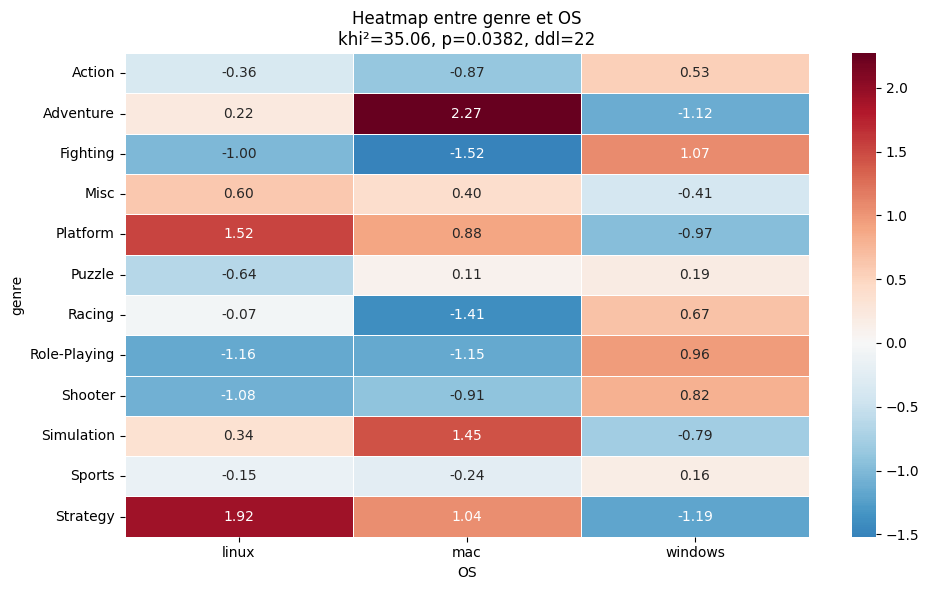

Khi² = 35.060652650931736
Degrés de liberté = 22
p_value = 0.0381834073448859
Résultat : dépendance significative entre genre et OS (p<0.05)


In [152]:
df_os = pd.merge(df, a_os, on="id_jeu")
df_os = pd.merge(df_os, os, on="id_os")

seuil = 0
top_os = df_os["OS"].value_counts()
top_os = top_os[top_os >= seuil].index

seuil_genre=0
top_genres = df_os["genre"].value_counts()
top_genres = top_genres[top_genres >= seuil_genre].index

df_filtre = df_os[
    df_os["OS"].isin(top_os) &
    df_os["genre"].isin(top_genres)
]

heatmap(df_filtre,"genre","OS")
khi2(df_filtre,"genre","OS",0.05)

## Genre et âge requis

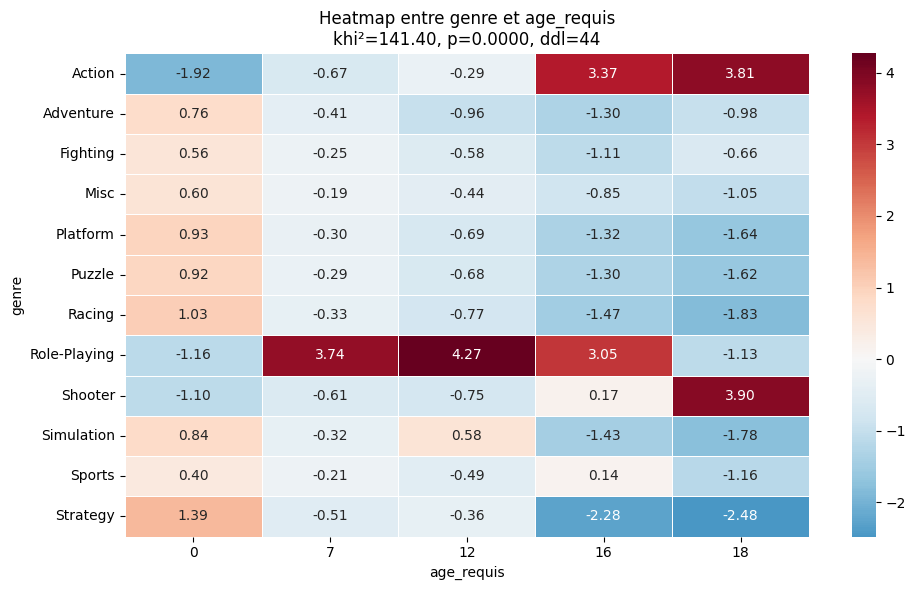

Condition non respectée : 66.7% des cellules < 5. On ne peut pas effectuer le test


In [153]:
seuil = 0
top_age = df["age_requis"].value_counts()
top_age = top_age[top_age >= seuil].index

seuil_genre=0
top_genres = df["genre"].value_counts()
top_genres = top_genres[top_genres >= seuil_genre].index

df_filtre = df[
    df["age_requis"].isin(top_age) &
    df["genre"].isin(top_genres)
]

heatmap(df_filtre,"genre","age_requis")
khi2(df_filtre,"genre","age_requis",0.05)

## Genre et année

Lignes avant filtre : 780
Lignes après filtre : 704
Années gardées : 11 / 19
Genres gardés : 12 / 12
genre
Action          174
Shooter         147
Strategy        101
Role-Playing     88
Adventure        66
Racing           42
Simulation       40
Platform         34
Puzzle           33
Fighting         24
Sports           17
Misc             14
Name: count, dtype: int64
annee
2014.0    93
2009.0    93
2015.0    80
2016.0    77
2011.0    68
2010.0    60
2008.0    57
2012.0    52
2013.0    45
2017.0    45
2018.0    34
2007.0    31
2006.0    10
2019.0     6
2004.0     2
1998.0     1
2000.0     1
2002.0     1
2005.0     1
Name: count, dtype: int64


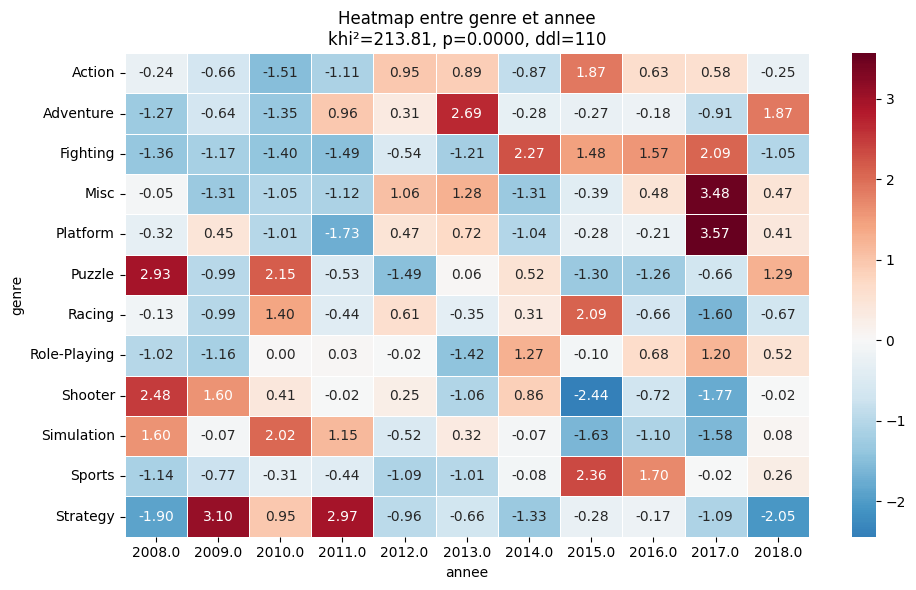

Condition non respectée : 60.6% des cellules < 5. On ne peut pas effectuer le test


In [154]:
seuil = 32
top_annee = df["annee"].value_counts()
top_annee = top_annee[top_annee >= seuil].index

seuil_genre=10
top_genres = df["genre"].value_counts()
top_genres = top_genres[top_genres >= seuil_genre].index

df_filtre = df[
    df["annee"].isin(top_annee) &
    df["genre"].isin(top_genres)
]

print(f"Lignes avant filtre : {len(df)}")
print(f"Lignes après filtre : {len(df_filtre)}")
print(f"Années gardées : {len(top_annee)} / {df['annee'].nunique()}")
print(f"Genres gardés : {len(top_genres)} / {df['genre'].nunique()}")

print(df["genre"].value_counts())   # quels genres sont exclus
print(df["annee"].value_counts())   # quelles années sont exclues

heatmap(df_filtre,"genre","annee")
khi2(df_filtre,"genre","annee",0.05)

## Editeur et développeur

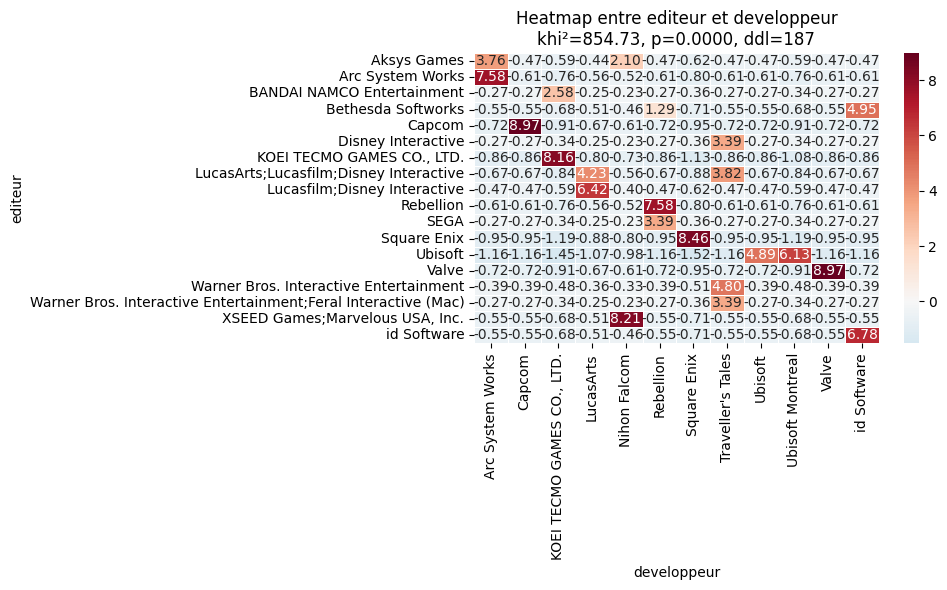

Condition non respectée : 100.0% des cellules < 5. On ne peut pas effectuer le test


In [171]:
df_ed_dev = pd.merge(editeur,dev,on="id_jeu")
df_ed_dev.head()

seuil =3
top_editeur = df_ed_dev["editeur"].value_counts()
top_editeur = top_editeur[top_editeur >= seuil].index

seuil_dev=7
top_dev = df_ed_dev["developpeur"].value_counts()
top_dev = top_dev[top_dev >= seuil_dev].index

df_filtre = df_ed_dev[
    df_ed_dev["editeur"].isin(top_editeur) &
    df_ed_dev["developpeur"].isin(top_dev)
]

heatmap(df_filtre,"editeur","developpeur")
khi2(df_ed_dev,"editeur","developpeur",0.05)

## Editeur et catégorie

Lignes avant filtre : 2954
Lignes après filtre : 1221
Editeurs gardés : 20 / 272
Catégories gardées : 15 / 21
editeur
Square Enix                               128
Ubisoft                                   115
THQ Nordic                                 99
BANDAI NAMCO Entertainment                 86
SEGA                                       83
Capcom                                     80
Deep Silver                                71
Bethesda Softworks                         68
Valve                                      59
Paradox Interactive                        57
Warner Bros. Interactive Entertainment     51
KOEI TECMO GAMES CO., LTD.                 49
2K                                         45
Kalypso Media Digital                      45
Degica                                     40
Spike Chunsoft Co., Ltd.                   40
Electronic Arts                            39
Activision                                 37
Codemasters                                36
LucasArt

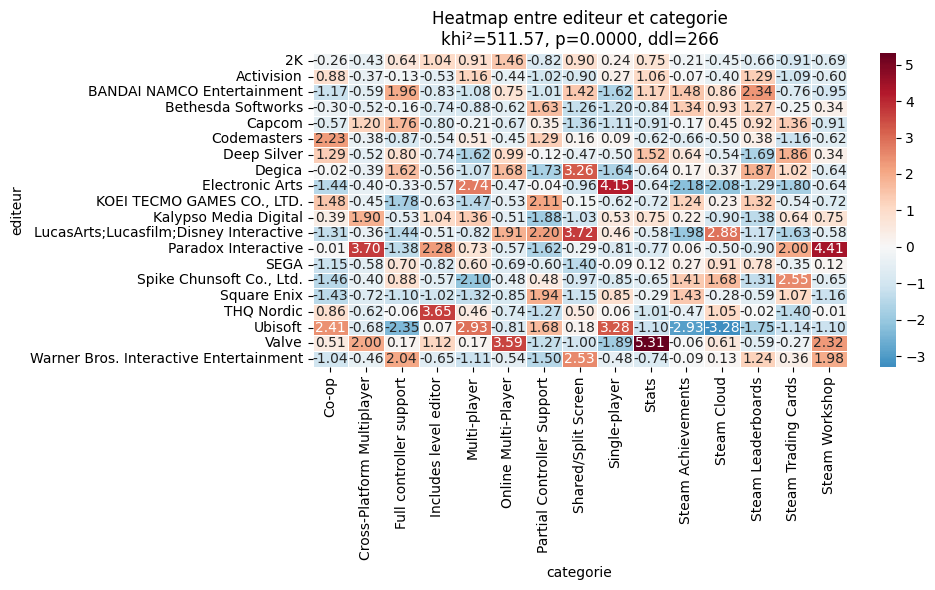

Condition non respectée : 72.0% des cellules < 5. On ne peut pas effectuer le test


In [176]:
df_ed_cat = pd.merge(editeur,a_cat,on="id_jeu")
df_ed_cat = pd.merge(df_ed_cat,cat,on="id_cat")
df_ed_cat.head()

seuil =35
top_editeur = df_ed_cat["editeur"].value_counts()
top_editeur = top_editeur[top_editeur >= seuil].index

seuil_cat=25
top_cat = df_ed_cat["categorie"].value_counts()
top_cat = top_cat[top_cat >= seuil_cat].index

df_filtre = df_ed_cat[
    df_ed_cat["editeur"].isin(top_editeur) &
    df_ed_cat["categorie"].isin(top_cat)
]

print(f"Lignes avant filtre : {len(df_ed_cat)}")
print(f"Lignes après filtre : {len(df_filtre)}")
print(f"Editeurs gardés : {df_filtre['editeur'].nunique()} / {df_ed_cat['editeur'].nunique()}")
print(f"Catégories gardées : {df_filtre['categorie'].nunique()} / {df_ed_cat['categorie'].nunique()}")
print(df_ed_cat['editeur'].value_counts().head(20))
print(df_ed_cat['categorie'].value_counts())

heatmap(df_filtre,"editeur","categorie")
khi2(df_filtre,"editeur","categorie",0.05)

## Editeur et tag

Lignes avant filtre : 10061
Lignes après filtre : 1583
Editeurs gardés : 15 / 272
Tags gardées : 10 / 311
editeur
Ubisoft                                                           732
Square Enix                                                       607
Electronic Arts                                                   403
SEGA                                                              347
Bethesda Softworks                                                279
THQ Nordic                                                        263
Capcom                                                            258
Deep Silver                                                       242
Rockstar Games                                                    242
Warner Bros. Interactive Entertainment                            224
BANDAI NAMCO Entertainment                                        209
2K                                                                193
Paradox Interactive                           

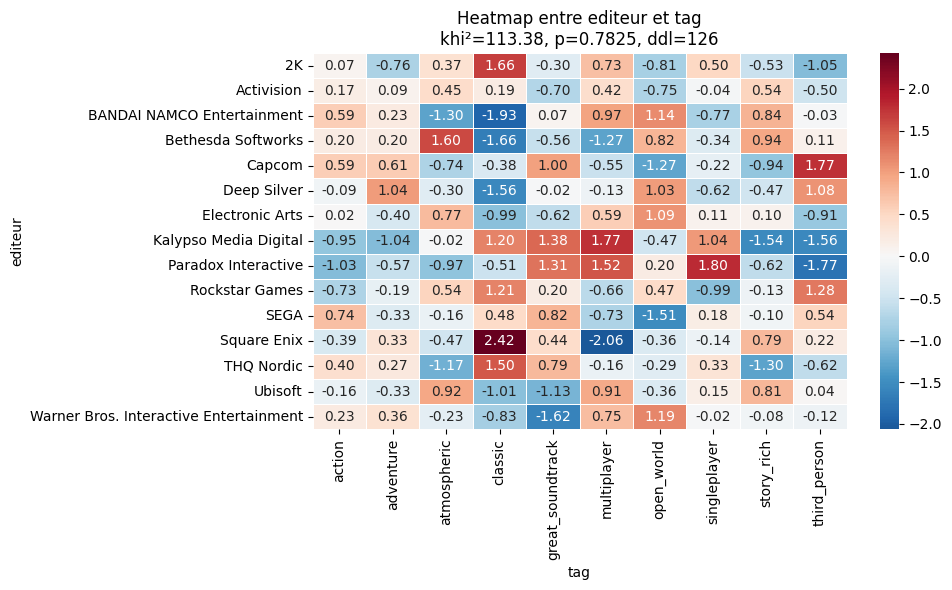

Khi² = 113.38421335822409
Degrés de liberté = 126
p_value = 0.7824624188966749
Résultat : pas de dépendance significative entre editeur et tag (p>=0.05)


In [191]:
df_ed_tag = pd.merge(editeur,a_tag,on="id_jeu")
df_ed_tag.head()

seuil =150
top_editeur = df_ed_tag["editeur"].value_counts()
top_editeur = top_editeur[top_editeur >= seuil].index

seuil_tag=200
top_tag = df_ed_tag["tag"].value_counts()
top_tag = top_tag[top_tag >= seuil_tag].index

df_filtre = df_ed_tag[
    df_ed_tag["editeur"].isin(top_editeur) &
    df_ed_tag["tag"].isin(top_tag)
]

print(f"Lignes avant filtre : {len(df_ed_tag)}")
print(f"Lignes après filtre : {len(df_filtre)}")
print(f"Editeurs gardés : {df_filtre['editeur'].nunique()} / {df_ed_tag['editeur'].nunique()}")
print(f"Tags gardées : {df_filtre['tag'].nunique()} / {df_ed_tag['tag'].nunique()}")
print(df_ed_tag['editeur'].value_counts().head(20))
print(df_ed_tag['tag'].value_counts())

heatmap(df_filtre,"editeur","tag")
khi2(df_filtre,"editeur","tag",0.05)

Parmi les 15 plus gros éditeurs, il n'y a pas de différence significative dans les tags associés à leurs jeux. On ne peut pas effectuer le test avec plus d'éditeurs.

## Editeur et OS

Lignes avant filtre : 1050
Lignes après filtre : 357
Editeurs gardés : 15 / 272
Tags gardées : 3 / 3
editeur
Ubisoft                                   50
Square Enix                               39
THQ Nordic                                37
Paradox Interactive                       26
Electronic Arts                           24
SEGA                                      24
Deep Silver                               22
Kalypso Media Digital                     20
Valve                                     20
2K                                        17
Capcom                                    16
Bethesda Softworks                        16
Codemasters                               16
Disney Interactive                        15
BANDAI NAMCO Entertainment                15
Rockstar Games                            13
Microids                                  12
2K;Aspyr (Mac);Aspyr (Linux)              12
Spike Chunsoft Co., Ltd.                  12
Warner Bros. Interactive Entertainme

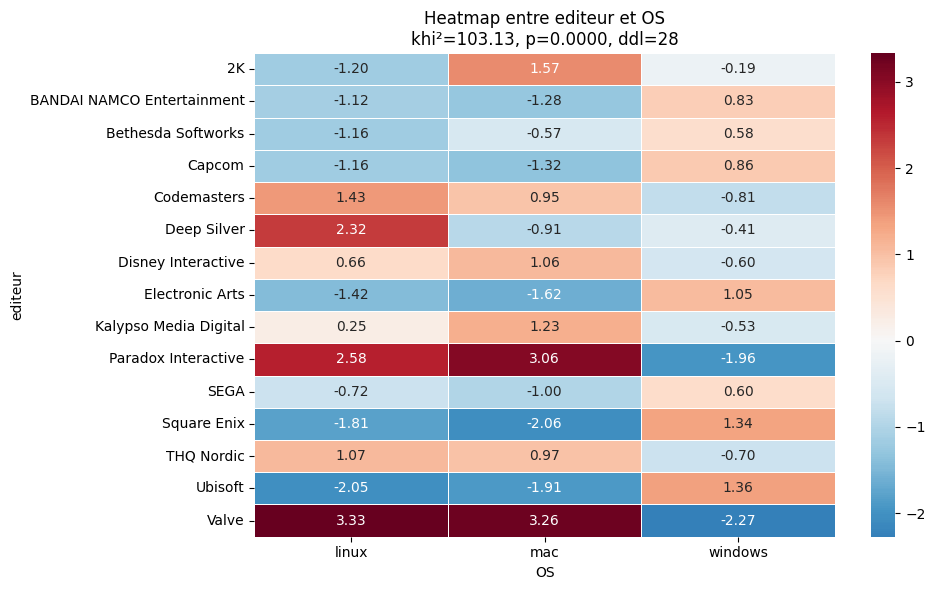

Condition non respectée : 64.4% des cellules < 5. On ne peut pas effectuer le test


In [ ]:
df_edit_os = pd.merge(editeur,a_os,on="id_jeu")
df_edit_os = pd.merge(df_edit_os,os,on="id_os")

seuil =14
top_editeur = df_edit_os["editeur"].value_counts()
top_editeur = top_editeur[top_editeur >= seuil].index

seuil_OS=0
top_OS = df_edit_os["OS"].value_counts()
top_OS = top_OS[top_OS >= seuil_OS].index

df_filtre = df_edit_os[
    df_edit_os["editeur"].isin(top_editeur) &
    df_edit_os["OS"].isin(top_OS)
]

print(f"Lignes avant filtre : {len(df_edit_os)}")
print(f"Lignes après filtre : {len(df_filtre)}")
print(f"Editeurs gardés : {df_filtre['editeur'].nunique()} / {df_edit_os['editeur'].nunique()}")
print(f"OS gardés : {df_filtre['OS'].nunique()} / {df_edit_os['OS'].nunique()}")
print(df_edit_os['editeur'].value_counts().head(20))
print(df_edit_os['OS'].value_counts())

heatmap(df_filtre,"editeur","OS")
khi2(df_filtre,"editeur","OS",0.05)

## Editeur et âge requis

Lignes avant filtre : 780
Lignes après filtre : 288
Editeurs gardés : 15 / 272
Age gardés : 5 / 5
editeur
Ubisoft                                   49
Square Enix                               39
THQ Nordic                                26
Electronic Arts                           24
SEGA                                      22
Deep Silver                               16
Capcom                                    16
Bethesda Softworks                        15
BANDAI NAMCO Entertainment                15
Kalypso Media Digital                     14
2K                                        13
Rockstar Games                            13
Paradox Interactive                       12
Warner Bros. Interactive Entertainment    12
KOEI TECMO GAMES CO., LTD.                11
LucasArts;Lucasfilm;Disney Interactive    10
Codemasters                               10
Activision                                10
Disney Interactive                        10
Strategy First                         

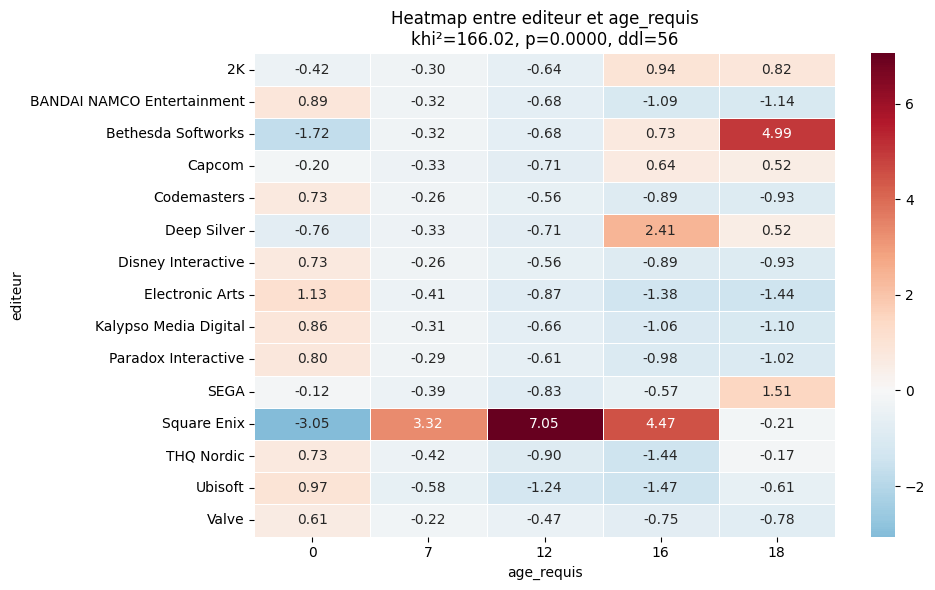

Condition non respectée : 80.0% des cellules < 5. On ne peut pas effectuer le test


In [204]:
df_edit_age = pd.merge(jeux,editeur,on="id_jeu")

seuil =14
top_editeur = df_edit_os["editeur"].value_counts()
top_editeur = top_editeur[top_editeur >= seuil].index

seuil_age_requis=0
top_age = df_edit_age["age_requis"].value_counts()
top_age = top_age[top_age >= seuil_age_requis].index

df_filtre = df_edit_age[
    df_edit_age["editeur"].isin(top_editeur) &
    df_edit_age["age_requis"].isin(top_age)
]

print(f"Lignes avant filtre : {len(df_edit_age)}")
print(f"Lignes après filtre : {len(df_filtre)}")
print(f"Editeurs gardés : {df_filtre['editeur'].nunique()} / {df_edit_age['editeur'].nunique()}")
print(f"Age gardés : {df_filtre['age_requis'].nunique()} / {df_edit_age['age_requis'].nunique()}")
print(df_edit_age['editeur'].value_counts().head(20))
print(df_edit_age['age_requis'].value_counts())

heatmap(df_filtre,"editeur","age_requis")
khi2(df_filtre,"editeur","age_requis",0.05)

## Editeur et année

Lignes avant filtre : 780
Lignes après filtre : 284
Editeurs gardés : 15 / 272
Années gardées : 19 / 19
editeur
Ubisoft                                   49
Square Enix                               39
THQ Nordic                                26
Electronic Arts                           24
SEGA                                      22
Deep Silver                               16
Capcom                                    16
Bethesda Softworks                        15
BANDAI NAMCO Entertainment                15
Kalypso Media Digital                     14
2K                                        13
Rockstar Games                            13
Paradox Interactive                       12
Warner Bros. Interactive Entertainment    12
KOEI TECMO GAMES CO., LTD.                11
LucasArts;Lucasfilm;Disney Interactive    10
Codemasters                               10
Activision                                10
Disney Interactive                        10
Strategy First                   

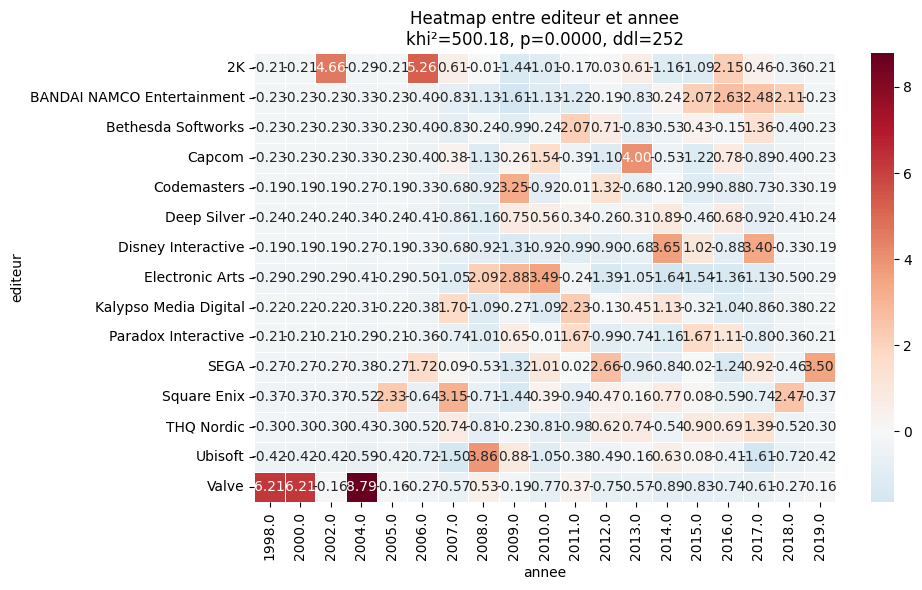

Condition non respectée : 98.9% des cellules < 5. On ne peut pas effectuer le test


In [205]:
df_edit_age = pd.merge(jeux,editeur,on="id_jeu")

seuil =14
top_editeur = df_edit_os["editeur"].value_counts()
top_editeur = top_editeur[top_editeur >= seuil].index

seuil_age_requis=0
top_age = df_edit_age["annee"].value_counts()
top_age = top_age[top_age >= seuil_age_requis].index

df_filtre = df_edit_age[
    df_edit_age["editeur"].isin(top_editeur) &
    df_edit_age["annee"].isin(top_age)
]

print(f"Lignes avant filtre : {len(df_edit_age)}")
print(f"Lignes après filtre : {len(df_filtre)}")
print(f"Editeurs gardés : {df_filtre['editeur'].nunique()} / {df_edit_age['editeur'].nunique()}")
print(f"Années gardées : {df_filtre['annee'].nunique()} / {df_edit_age['annee'].nunique()}")
print(df_edit_age['editeur'].value_counts().head(20))
print(df_edit_age['annee'].value_counts())

heatmap(df_filtre,"editeur","annee")
khi2(df_filtre,"editeur","annee",0.05)